# 04. Feature Selection + Baseline Modeling

**เป้าหมาย**
- ลดจำนวน feature ที่ไม่จำเป็น (Feature Selection)
- สร้าง Baseline Model ที่เรียบง่าย
- วัดผลด้วย metrics ที่เหมาะสมกับ class imbalance
- ได้จุดอ้างอิง (baseline) สำหรับเปรียบเทียบโมเดลที่ดีขึ้นในขั้นถัดไป

**Metrics ที่จะใช้**
- Accuracy (ดูภาพรวม)
- Macro-F1 (สำคัญที่สุด เพราะ class ไม่สมดุล)
- Weighted-F1
- Classification Report + Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, mutual_info_classif

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded')

Libraries loaded


## 4.1 โหลดข้อมูลที่ผ่าน Feature Engineering แล้ว

รัน notebook 03 ให้เสร็จก่อน (และทิ้ง ISO แล้ว) แล้วไฟล์เหล่านี้จะถูกสร้างขึ้น

In [2]:
X_train = pd.read_csv('X_train_fe.csv')
X_test = pd.read_csv('X_test_fe.csv')
y_train = pd.read_csv('y_train_fe.csv').squeeze()
y_test = pd.read_csv('y_test_fe.csv').squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'\nTarget distribution (train):')
print(y_train.value_counts())

X_train: (14204, 843)
X_test : (3552, 843)

Target distribution (train):
Target
Flood                  4946
Storm                  4042
Earthquake             1321
Epidemic               1298
Landslide               734
Drought                 642
Extreme temperature     584
Wildfire                411
Volcanic activity       226
Name: count, dtype: int64


## 4.2 Encode Target เป็นตัวเลข

In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print('Classes:', list(le.classes_))
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

Classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Volcanic activity', 'Wildfire']
Mapping: {'Drought': np.int64(0), 'Earthquake': np.int64(1), 'Epidemic': np.int64(2), 'Extreme temperature': np.int64(3), 'Flood': np.int64(4), 'Landslide': np.int64(5), 'Storm': np.int64(6), 'Volcanic activity': np.int64(7), 'Wildfire': np.int64(8)}


## 4.3 Feature Selection

เราจะใช้ 2 วิธีประกอบกัน:
1. **Mutual Information** – วัด dependency กับ target
2. **Random Forest Importance** – ดู feature สำคัญจาก tree

In [4]:
# 1) Mutual Information
mi_scores = mutual_info_classif(X_train, y_train_enc, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print('=== Top 20 Features by Mutual Information ===')
print(mi_df.head(20).to_string(index=False))

=== Top 20 Features by Mutual Information ===
                         feature  mi_score
             Magnitude Scale_Kph  0.601436
                       Magnitude  0.489021
Magnitude Scale_Moment Magnitude  0.308494
         Magnitude Scale_Unknown  0.296273
                    Country_freq  0.291943
                   duration_days  0.275788
           Associated Types_freq  0.244798
                  Origin_Unknown  0.229475
                  Subregion_freq  0.191492
              Magnitude Scale_°C  0.165319
                  Total Affected  0.157297
                    No. Affected  0.153798
                       Start Day  0.137871
                         End Day  0.130934
                    Total Deaths  0.114769
      Magnitude Scale_Vaccinated  0.109317
              Origin_Heavy rains  0.108045
                     No. Injured  0.094971
     has_Total Damage ('000 US$)  0.072455
                             CPI  0.072210


In [5]:
# 2) Random Forest Feature Importance
rf_selector = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train_enc)

imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print('=== Top 20 Features by Random Forest Importance ===')
print(imp_df.head(20).to_string(index=False))

=== Top 20 Features by Random Forest Importance ===
                         feature  importance
             Magnitude Scale_Kph    0.098311
         Magnitude Scale_Unknown    0.085111
Magnitude Scale_Moment Magnitude    0.076995
              Magnitude Scale_°C    0.075996
                       Magnitude    0.072000
                   duration_days    0.035603
                has_Total Deaths    0.033880
                    No. Affected    0.032371
                  Total Affected    0.032084
      Magnitude Scale_Vaccinated    0.029168
                  Origin_Unknown    0.026317
                  Subregion_freq    0.026226
                    Total Deaths    0.024691
                    Country_freq    0.021661
                       Start Day    0.018011
                        End Year    0.017723
                         End Day    0.016691
              Origin_Heavy rains    0.016376
                     No. Injured    0.015892
                             CPI    0.015781


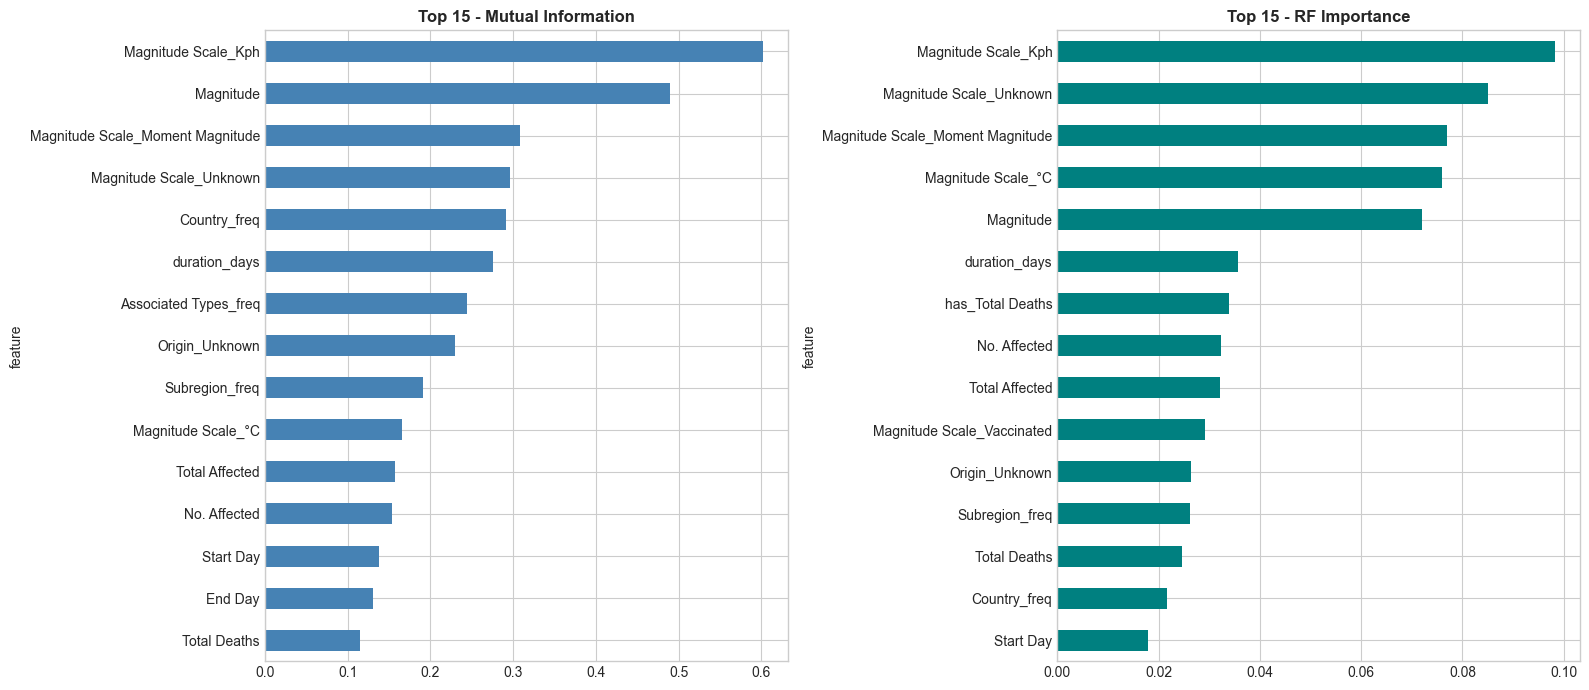

In [6]:
# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mi_df.head(15).plot(kind='barh', x='feature', y='mi_score', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Top 15 - Mutual Information', fontweight='bold')
axes[0].invert_yaxis()

imp_df.head(15).plot(kind='barh', x='feature', y='importance', ax=axes[1], color='teal', legend=False)
axes[1].set_title('Top 15 - RF Importance', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### เลือก Feature

เราจะเลือก feature ที่มี importance สูงจากทั้งสองวิธี (หรือใช้ threshold)

In [7]:
# วิธีง่าย: เลือก top N จาก RF importance (หรือใช้ SelectFromModel)
selector = SelectFromModel(rf_selector, prefit=True, threshold='median')  # เก็บที่สูงกว่า median

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()].tolist()
print(f'จำนวน feature เดิม: {X_train.shape[1]}')
print(f'จำนวน feature หลังเลือก: {len(selected_features)}')
print('\nSelected features:')
print(selected_features)

จำนวน feature เดิม: 843
จำนวน feature หลังเลือก: 422

Selected features:
['Magnitude', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'duration_days', 'decade', 'has_Total Deaths', 'has_No. Injured', 'has_No. Affected', 'has_No. Homeless', 'has_Total Affected', "has_Total Damage ('000 US$)", "has_Total Damage, Adjusted ('000 US$)", 'Historic_Yes', 'Region_Americas', 'Region_Asia', 'Region_Europe', 'Region_Oceania', 'Origin_Abundant snowmelt and heavy rains', 'Origin_Active monsoonal rainfall', 'Origin_After flood', 'Origin_After flooding', 'Origin_Bad distibution of rain, conflict and bad recolt', 'Origin_Barbecue and high winds', 'Origin_Basic infrastructure inefficient, water quality and sanitation poor', 'Origin_Below-average precipitation', 'Origin_Breakdown water supply, poor hygiene practices and inc

## 4.4 Baseline Models

เราจะลอง 2 โมเดลพื้นฐาน:
1. **Logistic Regression** (linear, เร็ว, interpretable)
2. **Random Forest** (non-linear, แข็งแรงกับ tabular data)

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, le, model_name='Model'):
    """Train + Evaluate แล้วแสดงผล"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    weighted_f1 = f1_score(y_te, y_pred, average='weighted')
    
    print(f'\n===== {model_name} =====')
    print(f'Accuracy   : {acc:.4f}')
    print(f'Macro-F1   : {macro_f1:.4f}')
    print(f'Weighted-F1: {weighted_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1}


===== Logistic Regression (Baseline) =====
Accuracy   : 0.3086
Macro-F1   : 0.3115
Weighted-F1: 0.3576

Classification Report:
                     precision    recall  f1-score   support

            Drought       0.48      0.42      0.44       161
         Earthquake       0.87      0.88      0.87       330
           Epidemic       0.28      0.11      0.16       324
Extreme temperature       0.31      0.32      0.31       146
              Flood       0.77      0.22      0.34      1237
          Landslide       0.14      0.30      0.19       184
              Storm       0.44      0.27      0.34      1011
  Volcanic activity       0.02      0.41      0.05        56
           Wildfire       0.06      0.28      0.10       103

           accuracy                           0.31      3552
          macro avg       0.37      0.36      0.31      3552
       weighted avg       0.54      0.31      0.36      3552



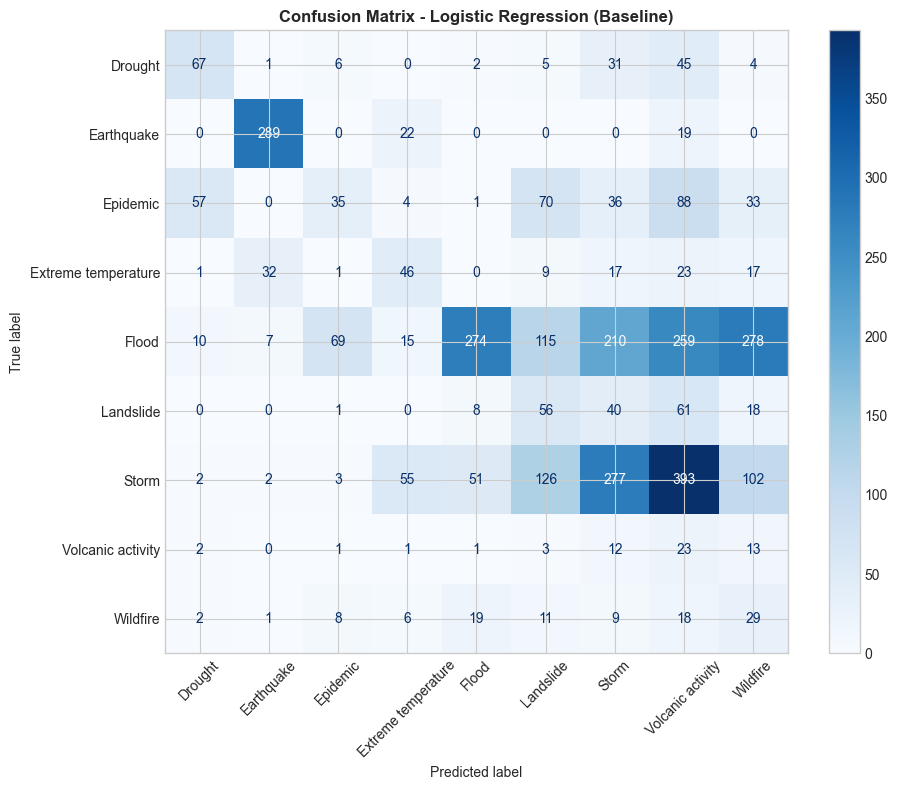

In [9]:
# Baseline 1: Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results_lr = evaluate_model(
    lr, X_train_sel, y_train_enc, X_test_sel, y_test_enc, le,
    model_name='Logistic Regression (Baseline)'
)


===== Random Forest (Baseline) =====
Accuracy   : 0.9085
Macro-F1   : 0.8500
Weighted-F1: 0.9141

Classification Report:
                     precision    recall  f1-score   support

            Drought       0.66      0.97      0.79       161
         Earthquake       1.00      1.00      1.00       330
           Epidemic       0.91      0.91      0.91       324
Extreme temperature       0.95      1.00      0.97       146
              Flood       0.98      0.81      0.89      1237
          Landslide       0.80      0.95      0.87       184
              Storm       0.99      1.00      0.99      1011
  Volcanic activity       0.67      0.80      0.73        56
           Wildfire       0.39      0.70      0.50       103

           accuracy                           0.91      3552
          macro avg       0.82      0.90      0.85      3552
       weighted avg       0.93      0.91      0.91      3552



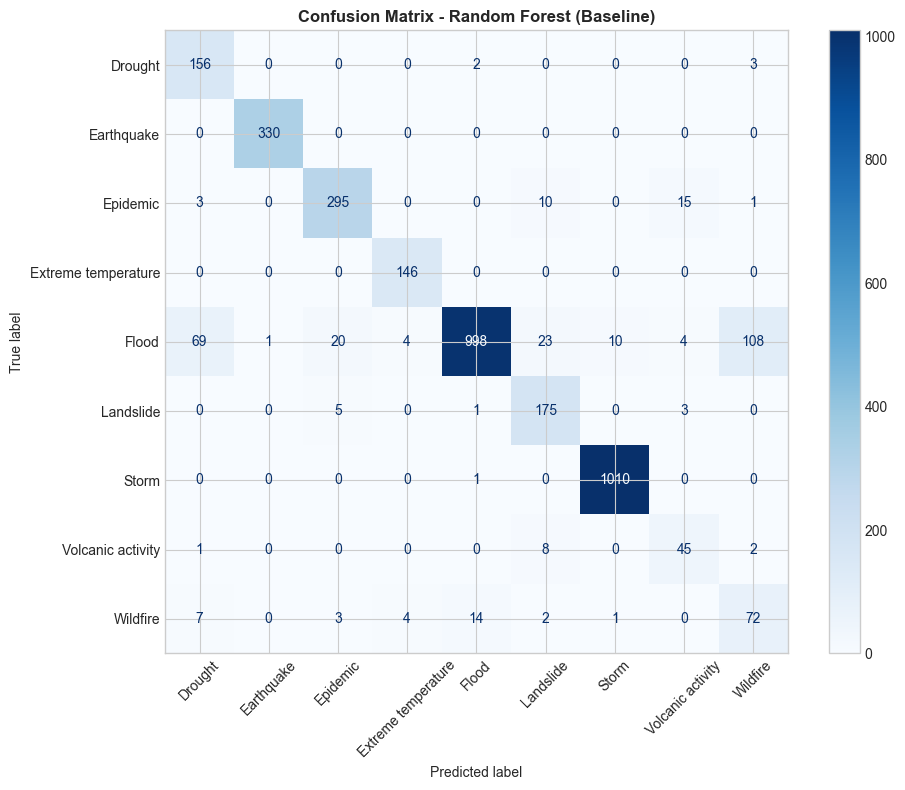

In [10]:
# Baseline 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results_rf = evaluate_model(
    rf, X_train_sel, y_train_enc, X_test_sel, y_test_enc, le,
    model_name='Random Forest (Baseline)'
)

## 4.5 เปรียบเทียบ Baseline + Cross-Validation

In [11]:
# Cross-validation (Macro-F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf
}

print('=== 5-Fold Cross-Validation (Macro-F1) ===')
for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train_enc, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f'{name:25s} | Mean: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

=== 5-Fold Cross-Validation (Macro-F1) ===
Logistic Regression       | Mean: 0.3087 (+/- 0.0093)
Random Forest             | Mean: 0.8350 (+/- 0.0134)


In [12]:
# สรุปผล
summary = pd.DataFrame([results_lr, results_rf])
print('\n=== สรุป Baseline Results (Test Set) ===')
print(summary.to_string(index=False))


=== สรุป Baseline Results (Test Set) ===
                         model  accuracy  macro_f1  weighted_f1
Logistic Regression (Baseline)  0.308559  0.311491     0.357648
      Random Forest (Baseline)  0.908502  0.850029     0.914137


## 4.6 สรุป + คำถามให้คิด

หลังจาก run แล้ว ให้ตอบคำถามเหล่านี้:

1. **โมเดลไหนดีกว่า** ระหว่าง Logistic Regression กับ Random Forest? (ดู Macro-F1 เป็นหลัก)
2. **Class ไหนที่โมเดลทายได้แย่ที่สุด?** (จาก Classification Report)
3. **Feature กลุ่มไหนสำคัญที่สุด** จาก MI และ RF Importance?
4. คุณคิดว่าควรไปทางไหนต่อ?
   - ปรับ Hyperparameter ของ Random Forest
   - ลองโมเดลที่แรงกว่า (XGBoost / LightGBM)
   - จัดการ class imbalance เพิ่ม (SMOTE, Focal Loss ฯลฯ)
   - ตัด feature ที่สงสัย leakage (Magnitude Scale, Impact)

ตอบมาได้เลย แล้วเราจะไปขั้น **Advanced Modeling** ต่อ